# Task 4: Reranker Performance Comparison

This notebook compares reranker architectures on top of the fixed retrieval-augmented generation pipeline selected earlier.

Fixed backbone reused from Task 3:
- sentence chunking with 3 sentences and overlap 1
- HNSW first-stage retrieval
- `M=32`, `efConstruction=120`, `metric='euclidean'`
- same prompt template and answer-scoring logic as Task 3

Baseline handling:
- the no-reranker condition is reused from Task 3
- only the new reranker conditions are computed here

Rerankers compared:
- `tfidf`
- `bow`
- `cross_encoder`
- `hybrid`
- `sequential`

Generator used:
- `qwen2.5:1.5b`

Evaluation:
- `exact_match`
- `transformer_match`

Reporting:
- overall scores by reranker
- stratified scores by `DifficultyFromAnswerer` for `easy`, `medium`, and `hard`

Memory-efficiency choices in this notebook:
- chunk embeddings are encoded and added to HNSW in batches
- the notebook does not keep all chunk embeddings in memory
- HNSW candidate pools are precomputed once per question
- reranked chunk ids are saved to disk and reused
- generated outputs are written to CSV incrementally instead of being kept entirely in RAM


In [1]:
import os
import sys
import time
import json
from pathlib import Path
from typing import List, Dict, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from openai import OpenAI

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("textwave exists:", (PROJECT_ROOT / "textwave").exists())

Project root: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main
textwave exists: True


In [3]:
from textwave.modules.extraction.preprocessing import DocumentProcessing
from textwave.modules.extraction.embedding import Embedding
from textwave.modules.utils.metrics import Matching
from textwave.modules.retrieval.reranker import Reranker
from hnsw import FaissHNSW

In [5]:
QUESTIONS_PATH_CANDIDATES = PROJECT_ROOT / "textwave" / "qa_resources" / "question.tsv",


QUESTIONS_PATH = next((p for p in QUESTIONS_PATH_CANDIDATES if p.exists()), None)
if QUESTIONS_PATH is None:
    raise FileNotFoundError("Could not find question.tsv in qa_resources or qa_storage.")

CORPUS_DIR = PROJECT_ROOT / "textwave" / "storage"

TASK3_RESULTS_DIR = PROJECT_ROOT / "analysis" / "results" / "task3_rag_hnsw_no_reranker"
BASELINE_RESULTS_PATH = TASK3_RESULTS_DIR / "task3_rag_hnsw_no_reranker_combined_results.csv"
if not BASELINE_RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Task 3 baseline results not found at: {BASELINE_RESULTS_PATH}\n"
        "Run the Task 3 notebook first, or point BASELINE_RESULTS_PATH to the saved combined CSV."
    )

RESULTS_DIR = PROJECT_ROOT / "analysis" / "results" / "task4"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
CHUNKING_CONFIG = {"num_sentences": 3, "overlap_size": 1}
HNSW_CONFIG = {"M": 32, "efConstruction": 120, "metric": "euclidean"}

GENERATOR_MODELS = ["qwen2.5:1.5b"]
RERANKER_TYPES = ["tfidf", "bow", "cross_encoder", "hybrid", "sequential"]

OLLAMA_BASE_URL = "http://localhost:11434/v1"
OLLAMA_API_KEY = "ollama"
TEMPERATURE = 0.2

TOP_K_CANDIDATE_POOL = 50
TOP_K_CONTEXT = 5
SEQUENTIAL_K1 = 20

# For quick testing, set this to a small number like 20.
MAX_QUESTIONS = None

CHUNK_EMBED_BATCH_SIZE = 256
QUERY_EMBED_BATCH_SIZE = 256
SAVE_EVERY = 25

print("Questions path:", QUESTIONS_PATH)
print("Corpus dir:", CORPUS_DIR)
print("Task 3 baseline path:", BASELINE_RESULTS_PATH)
print("Results dir:", RESULTS_DIR)
print("Chunking config:", CHUNKING_CONFIG)
print("HNSW config:", HNSW_CONFIG)
print("Generators:", GENERATOR_MODELS)
print("Rerankers:", RERANKER_TYPES)

Questions path: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\textwave\qa_resources\question.tsv
Corpus dir: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\textwave\storage
Task 3 baseline path: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task3_rag_hnsw_no_reranker\task3_rag_hnsw_no_reranker_combined_results.csv
Results dir: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task4
Chunking config: {'num_sentences': 3, 'overlap_size': 1}
HNSW config: {'M': 32, 'efConstruction': 120, 'metric': 'euclidean'}
Generators: ['qwen2.5:1.5b']
Rerankers: ['tfidf', 'bow', 'cross_encoder', 'hybrid', 'sequential']


## Load Task 3 baseline

Task 3 serves as the no-reranker baseline for this notebook. We import those saved rows and label them with `reranker = "none"` so that the final comparison table contains both the baseline and the newly computed reranker conditions.


In [6]:
baseline_df = pd.read_csv(BASELINE_RESULTS_PATH)

required_cols = {"row_id", "model", "question", "gold_answer", "difficulty", "generated_answer", "latency_sec"}
missing_required = required_cols - set(baseline_df.columns)
if missing_required:
    raise KeyError(f"Baseline CSV is missing required columns: {missing_required}")

baseline_df["reranker"] = "none"
baseline_df["rerank_latency_sec"] = 0.0
baseline_df["generation_latency_sec"] = baseline_df.get("latency_sec", np.nan)
baseline_df["candidate_pool_size"] = TOP_K_CANDIDATE_POOL
baseline_df["top_k_context"] = TOP_K_CONTEXT
baseline_df["retrieved_chunk_ids"] = baseline_df.get("retrieved_chunk_ids", np.nan)
baseline_df["reranked_chunk_ids"] = baseline_df.get("retrieved_chunk_ids", np.nan)

print("Baseline rows:", len(baseline_df))
print("Baseline models:", sorted(baseline_df["model"].dropna().unique().tolist()))
print("Baseline unique row_ids:", baseline_df["row_id"].nunique())
display(baseline_df.head())

Baseline rows: 1676
Baseline models: ['phi3:mini', 'qwen2.5:1.5b']
Baseline unique row_ids: 838


,row_id,model,question,gold_answer,difficulty,article_id_norm,generated_answer,latency_sec,generation_error,retrieved_chunk_ids,exact_match,transformer_match,reranker,rerank_latency_sec,generation_latency_sec,candidate_pool_size,top_k_context,reranked_chunk_ids
0,0,qwen2.5:1.5b,Was Abraham Lincoln the sixteenth President of...,yes,easy,S08_set3_a4,"Yes, Abraham Lincoln was indeed the sixteenth ...",17.963971,NaN,"[3023, 3114, 3027, 3033, 3055]",1.0,1.0,none,0.0,17.963971,50,5,"[3023, 3114, 3027, 3033, 3055]"
1,1,qwen2.5:1.5b,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,S08_set3_a4,"Yes, Abraham Lincoln was indeed the sixteenth ...",0.929065,NaN,"[3023, 3114, 3027, 3033, 3055]",1.0,1.0,none,0.0,0.929065,50,5,"[3023, 3114, 3027, 3033, 3055]"
2,2,qwen2.5:1.5b,Did Lincoln sign the National Banking Act of 1...,yes,medium,S08_set3_a4,No context,9.347436,NaN,"[3189, 3187, 3190, 3180, 3127]",0.0,0.0,none,0.0,9.347436,50,5,"[3189, 3187, 3190, 3180, 3127]"
3,3,qwen2.5:1.5b,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,S08_set3_a4,No context,2.320464,NaN,"[3189, 3187, 3190, 3180, 3127]",0.0,0.0,none,0.0,2.320464,50,5,"[3189, 3187, 3190, 3180, 3127]"
4,4,qwen2.5:1.5b,Did his mother die of pneumonia?,no,medium,S08_set3_a4,No context.,8.402469,NaN,"[3786, 2868, 4823, 8604, 3603]",1.0,1.0,none,0.0,8.402469,50,5,"[3786, 2868, 4823, 8604, 3603]"


## Load and clean the evaluation set, then align it to the Task 3 baseline

We begin from the same ``question.tsv`` benchmark file used in the earlier tasks, but we do not evaluate every raw row directly. First, the notebook performs the same basic cleaning needed for retrieval-augmented evaluation: it keeps only questions with non-empty question text, non-empty gold answers, and a valid source article that can be matched to one of the available ``.clean`` corpus files. This ensures that every retained row is actually usable for end-to-end RAG evaluation.

The crucial additional step is alignment with Task 3. Task 4 is meant to compare rerankers against the same no-reranker baseline established in Task 3, not against a slightly different subset of questions created by independent preprocessing. For that reason, the notebook takes the set of ``row_ids`` that were successfully evaluated in Task 3 (``baseline_row_ids``) and filters the cleaned question table down to exactly those rows.

In [7]:
def normalize_article_id(value: str) -> str:
    value = Path(str(value)).name
    for suffix in [".txt.clean", ".clean", ".txt"]:
        if value.endswith(suffix):
            value = value[:-len(suffix)]
    return value

def safe_text(x) -> str:
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return x if isinstance(x, str) else str(x)

ANSWER_COLUMN_CANDIDATES = [
    "Answer", "Answers", "answer", "answers",
    "GoldAnswer", "gold_answer", "ExpectedAnswer", "expected_answer"
]

questions_df = pd.read_csv(QUESTIONS_PATH, sep="\t")
ANSWER_COLUMN = next((col for col in ANSWER_COLUMN_CANDIDATES if col in questions_df.columns), None)
if ANSWER_COLUMN is None:
    raise KeyError("Could not find an answer column in question.tsv.")

corpus_files = sorted(CORPUS_DIR.glob("*.clean"))
available_article_ids = {normalize_article_id(path.name) for path in corpus_files}

questions_df["question_text"] = questions_df["Question"].apply(safe_text)
questions_df["gold_answer"] = questions_df[ANSWER_COLUMN].apply(safe_text)
questions_df["article_id_norm"] = questions_df["ArticleFile"].apply(safe_text).map(normalize_article_id)
questions_df["difficulty"] = questions_df["DifficultyFromAnswerer"].apply(safe_text).str.strip().str.lower()

questions_df = questions_df[
    (questions_df["question_text"].str.strip() != "") &
    (questions_df["gold_answer"].str.strip() != "") &
    (questions_df["article_id_norm"].str.strip() != "") &
    (questions_df["article_id_norm"].isin(available_article_ids))
].copy()

baseline_row_ids = set(baseline_df["row_id"].dropna().astype(int).tolist())
questions_df = questions_df.reset_index(drop=True)
questions_df["row_id"] = np.arange(len(questions_df))
questions_df = questions_df[questions_df["row_id"].isin(baseline_row_ids)].copy()

if MAX_QUESTIONS is not None:
    keep_row_ids = sorted(questions_df["row_id"].tolist())[:MAX_QUESTIONS]
    questions_df = questions_df[questions_df["row_id"].isin(keep_row_ids)].copy()
    baseline_df = baseline_df[baseline_df["row_id"].isin(keep_row_ids)].copy()

questions_df = questions_df.sort_values("row_id").reset_index(drop=True)

print("Questions kept for reranker notebook:", len(questions_df))
print("Baseline rows after alignment:", len(baseline_df))
print("Unique aligned row_ids:", questions_df["row_id"].nunique())
print("Difficulty counts:")
display(questions_df["difficulty"].value_counts(dropna=False).rename_axis("difficulty").reset_index(name="rows"))
display(questions_df.head())

Questions kept for reranker notebook: 838
Baseline rows after alignment: 1676
Unique aligned row_ids: 838
Difficulty counts:


,difficulty,rows
0,easy,322
1,medium,304
2,hard,181
3,too hard,25
4,too easy,6


,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,ArticleFile,question_text,gold_answer,article_id_norm,difficulty,row_id
0,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,yes,easy,easy,S08_set3_a4,Was Abraham Lincoln the sixteenth President of...,yes,S08_set3_a4,easy,0
1,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,easy,S08_set3_a4,Was Abraham Lincoln the sixteenth President of...,Yes.,S08_set3_a4,easy,1
2,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,yes,easy,medium,S08_set3_a4,Did Lincoln sign the National Banking Act of 1...,yes,S08_set3_a4,medium,2
3,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,easy,S08_set3_a4,Did Lincoln sign the National Banking Act of 1...,Yes.,S08_set3_a4,easy,3
4,Abraham_Lincoln,Did his mother die of pneumonia?,no,easy,medium,S08_set3_a4,Did his mother die of pneumonia?,no,S08_set3_a4,medium,4


## Build the sentence-based chunk table

This uses the same chunking strategy as Task 3:
- 3 sentences per chunk
- overlap of 1 sentence


In [8]:
processor = DocumentProcessing()
embedder = Embedding(EMBEDDING_MODEL_NAME)
matcher = Matching()

def build_chunk_table(
    corpus_paths: List[Path],
    processor: DocumentProcessing,
    num_sentences: int,
    overlap_size: int,
) -> pd.DataFrame:
    rows = []

    for file_path in corpus_paths:
        article_file = file_path.name
        article_id = normalize_article_id(article_file)

        chunks = processor.sentence_chunking(
            str(file_path),
            num_sentences=num_sentences,
            overlap_size=overlap_size,
        )

        for chunk_order, chunk_text in enumerate(chunks):
            rows.append(
                {
                    "chunk_id": len(rows),
                    "article_file": article_file,
                    "article_id": article_id,
                    "chunk_text": safe_text(chunk_text),
                    "chunk_order": chunk_order,
                    "num_sentences": num_sentences,
                    "overlap_size": overlap_size,
                }
            )

    chunk_df = pd.DataFrame(rows)
    if not chunk_df.empty:
        chunk_df["chunk_id"] = np.arange(len(chunk_df))
    return chunk_df

chunk_df = build_chunk_table(
    corpus_paths=corpus_files,
    processor=processor,
    num_sentences=CHUNKING_CONFIG["num_sentences"],
    overlap_size=CHUNKING_CONFIG["overlap_size"],
)

print("Chunk count:", len(chunk_df))
display(chunk_df.head())

Using device: cpu
Chunk count: 17161


,chunk_id,article_file,article_id,chunk_text,chunk_order,num_sentences,overlap_size
0,0,S08_set1_a1.txt.clean,S08_set1_a1,kangaroo A kangaroo is a marsupial from the fa...,0,3,1
1,1,S08_set1_a1.txt.clean,S08_set1_a1,The family also includes many smaller species ...,1,3,1
2,2,S08_set1_a1.txt.clean,S08_set1_a1,"In general, larger kangaroos have adapted much...",2,3,1
3,3,S08_set1_a1.txt.clean,S08_set1_a1,"Steve Dow: ""An industry that's under the gun""....",3,3,1
4,4,S08_set1_a1.txt.clean,S08_set1_a1,The kangaroo is an Australian icon: it is feat...,4,3,1


## Build the HNSW index in batches

To keep memory use lower, this notebook does not keep the full chunk embedding matrix in memory. Instead, chunk texts are encoded in batches and added to the HNSW index incrementally.


In [9]:
def encode_texts_in_batches(texts: List[str], embedder: Embedding, batch_size: int) -> np.ndarray:
    batches = []
    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        batch_vectors = embedder.encode(batch_texts)
        batch_vectors = np.asarray(batch_vectors, dtype=np.float32)
        if batch_vectors.ndim == 1:
            batch_vectors = batch_vectors.reshape(1, -1)
        batches.append(batch_vectors)
    return np.vstack(batches)

def build_hnsw_index_incremental(
    chunk_df: pd.DataFrame,
    embedder: Embedding,
    batch_size: int,
    **kwargs,
):
    probe_vec = embedder.encode([safe_text(chunk_df.iloc[0]["chunk_text"])])
    probe_vec = np.asarray(probe_vec, dtype=np.float32)
    if probe_vec.ndim == 1:
        probe_vec = probe_vec.reshape(1, -1)

    index = FaissHNSW(dim=probe_vec.shape[1], **kwargs)

    for start in range(0, len(chunk_df), batch_size):
        batch_df = chunk_df.iloc[start:start + batch_size]
        batch_texts = batch_df["chunk_text"].tolist()
        batch_embeddings = embedder.encode(batch_texts)
        batch_embeddings = np.asarray(batch_embeddings, dtype=np.float32)
        if batch_embeddings.ndim == 1:
            batch_embeddings = batch_embeddings.reshape(1, -1)

        metadata = batch_df["chunk_id"].tolist()
        index.add_embeddings(batch_embeddings, metadata)

    return index, int(probe_vec.shape[1])

hnsw_index, embedding_dim = build_hnsw_index_incremental(
    chunk_df=chunk_df,
    embedder=embedder,
    batch_size=CHUNK_EMBED_BATCH_SIZE,
    **HNSW_CONFIG,
)

print("Built HNSW index.")
print("Embedding dim:", embedding_dim)

Built HNSW index.
Embedding dim: 384


## Encode the aligned evaluation questions and precompute candidate pools

Candidate pools are retrieved once from HNSW and then reused across all rerankers and both generators. This saves time and avoids repeating the first-stage retrieval work.

In [10]:
question_embeddings = encode_texts_in_batches(
    questions_df["question_text"].tolist(),
    embedder=embedder,
    batch_size=QUERY_EMBED_BATCH_SIZE,
)

print("Question embedding shape:", question_embeddings.shape)

def search_hnsw_indices(index_obj, query_vector: np.ndarray, top_k: int) -> np.ndarray:
    query_vector = np.asarray(query_vector, dtype=np.float32).reshape(1, -1)
    distances, indices = index_obj.index.search(query_vector, top_k)
    valid_indices = [int(i) for i in indices[0] if int(i) >= 0]
    return np.asarray(valid_indices, dtype=int)

candidate_pool_records = []
for i, row in questions_df.iterrows():
    pool_indices = search_hnsw_indices(hnsw_index, question_embeddings[i], TOP_K_CANDIDATE_POOL)
    candidate_pool_records.append(
        {
            "row_id": int(row["row_id"]),
            "candidate_chunk_ids": json.dumps(pool_indices.tolist()),
        }
    )

candidate_pool_df = pd.DataFrame(candidate_pool_records)
candidate_pool_path = RESULTS_DIR / "candidate_pools_hnsw.csv"
candidate_pool_df.to_csv(candidate_pool_path, index=False)

print("Saved candidate pools to:", candidate_pool_path)
display(candidate_pool_df.head())

Question embedding shape: (838, 384)
Saved candidate pools to: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task4\candidate_pools_hnsw.csv


,row_id,candidate_chunk_ids
0,0,"[3023, 3114, 3027, 3033, 3055, 3185, 3221, 320..."
1,1,"[3023, 3114, 3027, 3033, 3055, 3185, 3221, 320..."
2,2,"[3189, 3187, 3190, 3180, 3127, 3092, 3179, 316..."
3,3,"[3189, 3187, 3190, 3180, 3127, 3092, 3179, 316..."
4,4,"[3786, 4823, 8604, 16769, 14490, 16230, 3781, ..."


## Generator and scoring helpers

These reuse the same prompt style and the same answer-scoring logic as Task 3, so that changes in results can be attributed to reranking rather than to changes in prompting.


In [11]:
class RAGGeneratorOpenAI:
    def __init__(
        self,
        api_key: str = OLLAMA_API_KEY,
        temperature: float = TEMPERATURE,
        generator_model: str = "qwen2.5:1.5b",
        base_url: str = OLLAMA_BASE_URL,
    ):
        self.api_key = api_key
        self.temperature = temperature
        self.generator_model = generator_model
        self.client = OpenAI(api_key=api_key, base_url=base_url)

    def generate_answer(self, query: str, context: List[str]) -> str:
        combined_input = (
            f"Question: {safe_text(query)}\n\n"
            f"Context: {', '.join([safe_text(chunk) for chunk in context])}\n\n"
        )

        response = self.client.chat.completions.create(
            model=self.generator_model,
            temperature=self.temperature,
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You must answer the user's questions only based "
                        "on the provided context. Do not use any external or prior knowledge. "
                        "Provide clear, concise, and full-sentence answers. "
                        "If the context does not mention the answer, respond with 'No context'."
                    ),
                },
                {
                    "role": "user",
                    "content": combined_input,
                },
            ],
        )

        return safe_text(response.choices[0].message.content).strip()

def score_single_answer(question: str, gold_answer: str, generated_answer: str) -> Dict[str, Any]:
    question = safe_text(question)
    gold_answer = safe_text(gold_answer)
    generated_answer = safe_text(generated_answer)

    em = matcher.exact_match(generated_answer, gold_answer)

    try:
        _, transformer_match = matcher.transformer_match(
            generated_answer=generated_answer,
            ground_truth_answer=gold_answer,
            question=question,
        )
    except Exception:
        transformer_match = np.nan

    return {
        "exact_match": float(bool(em)),
        "transformer_match": float(bool(transformer_match)) if not pd.isna(transformer_match) else np.nan,
    }

## Precompute reranked context selections once per reranker

Reranked chunk ids do not depend on the generator model, so they are computed once per reranker and then reused for `qwen2.5:1.5b`. This reduces total runtime substantially.

In [12]:
def get_candidate_texts(candidate_chunk_ids: List[int], chunk_df: pd.DataFrame) -> List[str]:
    return chunk_df.iloc[candidate_chunk_ids]["chunk_text"].tolist()

def precompute_reranked_pools(
    reranker_type: str,
    questions: pd.DataFrame,
    candidate_pool_df: pd.DataFrame,
    chunk_df: pd.DataFrame,
    top_k_context: int,
    seq_k1: int,
) -> pd.DataFrame:
    reranker = Reranker(type=reranker_type)
    records = []

    pool_map = {
        int(row["row_id"]): json.loads(row["candidate_chunk_ids"])
        for _, row in candidate_pool_df.iterrows()
    }

    for _, row in questions.iterrows():
        row_id = int(row["row_id"])
        query = row["question_text"]
        candidate_chunk_ids = pool_map[row_id]
        candidate_texts = get_candidate_texts(candidate_chunk_ids, chunk_df)

        t0 = time.perf_counter()
        if reranker_type == "sequential":
            _, local_indices, _ = reranker.rerank(
                query=query,
                context=candidate_texts,
                distance_metric="cosine",
                seq_k1=min(seq_k1, len(candidate_texts)),
                seq_k2=min(top_k_context, len(candidate_texts)),
            )
        else:
            _, local_indices, _ = reranker.rerank(
                query=query,
                context=candidate_texts,
                distance_metric="cosine",
            )
        rerank_latency_sec = time.perf_counter() - t0

        local_indices = list(local_indices)[:top_k_context]
        reranked_chunk_ids = [int(candidate_chunk_ids[idx]) for idx in local_indices if idx < len(candidate_chunk_ids)]

        records.append(
            {
                "row_id": row_id,
                "reranker": reranker_type,
                "rerank_latency_sec": rerank_latency_sec,
                "candidate_chunk_ids": json.dumps(candidate_chunk_ids),
                "reranked_chunk_ids": json.dumps(reranked_chunk_ids),
            }
        )

    reranked_df = pd.DataFrame(records)
    save_path = RESULTS_DIR / f"reranked_pools_{reranker_type}.csv"
    reranked_df.to_csv(save_path, index=False)
    print(f"Saved reranked pools for {reranker_type} to: {save_path}")
    return reranked_df

In [13]:
all_reranked_pool_dfs = []

for reranker_type in RERANKER_TYPES:
    print(f"Precomputing reranked pools for: {reranker_type}")
    reranked_df = precompute_reranked_pools(
        reranker_type=reranker_type,
        questions=questions_df,
        candidate_pool_df=candidate_pool_df,
        chunk_df=chunk_df,
        top_k_context=TOP_K_CONTEXT,
        seq_k1=SEQUENTIAL_K1,
    )
    all_reranked_pool_dfs.append(reranked_df)

all_reranked_pool_df = pd.concat(all_reranked_pool_dfs, ignore_index=True)
display(all_reranked_pool_df.head())

Precomputing reranked pools for: tfidf
Saved reranked pools for tfidf to: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task4\reranked_pools_tfidf.csv
Precomputing reranked pools for: bow
Saved reranked pools for bow to: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task4\reranked_pools_bow.csv
Precomputing reranked pools for: cross_encoder
Saved reranked pools for cross_encoder to: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task4\reranked_pools_cross_encoder.csv
Precomputing reranked pools for: hybrid
Saved reranked pools for hybrid to: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task4\reranked_pools_hybrid.csv
Precomputing reranked pools for: sequential
Saved reranked pools for sequential to: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\

,row_id,reranker,rerank_latency_sec,candidate_chunk_ids,reranked_chunk_ids
0,0,tfidf,0.027922,"[3023, 3114, 3027, 3033, 3055, 3185, 3221, 320...","[3023, 3114, 3027, 2964, 3365]"
1,1,tfidf,0.010859,"[3023, 3114, 3027, 3033, 3055, 3185, 3221, 320...","[3023, 3114, 3027, 2964, 3365]"
2,2,tfidf,0.010559,"[3189, 3187, 3190, 3180, 3127, 3092, 3179, 316...","[3189, 2975, 3133, 3132, 3167]"
3,3,tfidf,0.012897,"[3189, 3187, 3190, 3180, 3127, 3092, 3179, 316...","[3189, 2975, 3133, 3132, 3167]"
4,4,tfidf,0.009654,"[3786, 4823, 8604, 16769, 14490, 16230, 3781, ...","[16230, 3889, 16231, 4823, 8604]"


## Run generation for each reranker

Only the reranker conditions are generated here. The `reranker = "none"` baseline is imported from Task 3 and will be added later to the combined result table.


In [14]:
def run_generation_for_condition(
    model_name: str,
    reranker_type: str,
    questions: pd.DataFrame,
    reranked_pool_df: pd.DataFrame,
    chunk_df: pd.DataFrame,
    save_every: int = SAVE_EVERY,
) -> pd.DataFrame:
    generator = RAGGeneratorOpenAI(generator_model=model_name)
    batch_rows = []
    all_rows = []

    output_path = RESULTS_DIR / f"generated_{model_name.replace(':', '_').replace('.', '_')}_{reranker_type}.csv"

    pool_map = {
        int(row["row_id"]): {
            "rerank_latency_sec": float(row["rerank_latency_sec"]),
            "candidate_chunk_ids": json.loads(row["candidate_chunk_ids"]),
            "reranked_chunk_ids": json.loads(row["reranked_chunk_ids"]),
        }
        for _, row in reranked_pool_df.iterrows()
    }

    start_all = time.perf_counter()

    for i, row in questions.iterrows():
        row_id = int(row["row_id"])
        pool_info = pool_map[row_id]

        reranked_chunk_ids = pool_info["reranked_chunk_ids"]
        context_chunks = chunk_df.iloc[reranked_chunk_ids]["chunk_text"].tolist()

        generation_error = ""
        generated_answer = ""

        t0 = time.perf_counter()
        try:
            generated_answer = generator.generate_answer(row["question_text"], context_chunks)
        except Exception as e:
            generation_error = str(e)
        generation_latency_sec = time.perf_counter() - t0

        score_dict = score_single_answer(row["question_text"], row["gold_answer"], generated_answer) if not generation_error else {
            "exact_match": 0.0,
            "transformer_match": np.nan,
        }

        record = {
            "row_id": row_id,
            "model": model_name,
            "reranker": reranker_type,
            "question": row["question_text"],
            "gold_answer": row["gold_answer"],
            "difficulty": row["difficulty"],
            "article_id_norm": row["article_id_norm"],
            "generated_answer": generated_answer,
            "generation_error": generation_error,
            "candidate_pool_size": TOP_K_CANDIDATE_POOL,
            "top_k_context": TOP_K_CONTEXT,
            "retrieved_chunk_ids": json.dumps(pool_info["candidate_chunk_ids"]),
            "reranked_chunk_ids": json.dumps(reranked_chunk_ids),
            "rerank_latency_sec": float(pool_info["rerank_latency_sec"]),
            "generation_latency_sec": generation_latency_sec,
            "latency_sec": float(pool_info["rerank_latency_sec"]) + generation_latency_sec,
            **score_dict,
        }

        batch_rows.append(record)
        all_rows.append(record)

        if (i + 1) % save_every == 0 or (i + 1) == len(questions):
            batch_df = pd.DataFrame(batch_rows)
            if output_path.exists():
                batch_df.to_csv(output_path, mode="a", header=False, index=False)
            else:
                batch_df.to_csv(output_path, index=False)
            batch_rows = []

            elapsed_min = (time.perf_counter() - start_all) / 60
            avg_per_q = (time.perf_counter() - start_all) / max(i + 1, 1)
            print(
                f"[{model_name} | {reranker_type}] {i+1}/{len(questions)} done | "
                f"elapsed: {elapsed_min:.1f} min | avg/question: {avg_per_q:.2f} sec"
            )

    return pd.DataFrame(all_rows)

In [15]:
new_result_dfs = []

for reranker_type in RERANKER_TYPES:
    reranked_pool_df = all_reranked_pool_df[all_reranked_pool_df["reranker"] == reranker_type].copy()

    for model_name in GENERATOR_MODELS:
        print(f"\nRunning generation for model={model_name}, reranker={reranker_type}")
        result_df = run_generation_for_condition(
            model_name=model_name,
            reranker_type=reranker_type,
            questions=questions_df,
            reranked_pool_df=reranked_pool_df,
            chunk_df=chunk_df,
            save_every=SAVE_EVERY,
        )
        new_result_dfs.append(result_df)

new_results_df = pd.concat(new_result_dfs, ignore_index=True)
new_results_path = RESULTS_DIR / "task4_new_reranker_results.csv"
new_results_df.to_csv(new_results_path, index=False)

print("Saved new reranker results to:", new_results_path)
display(new_results_df.head())


Running generation for model=qwen2.5:1.5b, reranker=tfidf
[qwen2.5:1.5b | tfidf] 25/838 done | elapsed: 4.4 min | avg/question: 10.52 sec
[qwen2.5:1.5b | tfidf] 50/838 done | elapsed: 11.4 min | avg/question: 13.64 sec
[qwen2.5:1.5b | tfidf] 75/838 done | elapsed: 16.3 min | avg/question: 13.01 sec
[qwen2.5:1.5b | tfidf] 100/838 done | elapsed: 21.9 min | avg/question: 13.16 sec
[qwen2.5:1.5b | tfidf] 125/838 done | elapsed: 28.6 min | avg/question: 13.72 sec
[qwen2.5:1.5b | tfidf] 150/838 done | elapsed: 36.1 min | avg/question: 14.44 sec
[qwen2.5:1.5b | tfidf] 175/838 done | elapsed: 43.9 min | avg/question: 15.04 sec
[qwen2.5:1.5b | tfidf] 200/838 done | elapsed: 52.9 min | avg/question: 15.87 sec
[qwen2.5:1.5b | tfidf] 225/838 done | elapsed: 59.0 min | avg/question: 15.72 sec
[qwen2.5:1.5b | tfidf] 250/838 done | elapsed: 63.6 min | avg/question: 15.26 sec
[qwen2.5:1.5b | tfidf] 275/838 done | elapsed: 68.5 min | avg/question: 14.94 sec
[qwen2.5:1.5b | tfidf] 300/838 done | elaps

,row_id,model,reranker,question,gold_answer,difficulty,article_id_norm,generated_answer,generation_error,candidate_pool_size,top_k_context,retrieved_chunk_ids,reranked_chunk_ids,rerank_latency_sec,generation_latency_sec,latency_sec,exact_match,transformer_match
0,0,qwen2.5:1.5b,tfidf,Was Abraham Lincoln the sixteenth President of...,yes,easy,S08_set3_a4,"Yes, Abraham Lincoln was indeed the sixteenth ...",,50,5,"[3023, 3114, 3027, 3033, 3055, 3185, 3221, 320...","[3023, 3114, 3027, 2964, 3365]",0.027922,23.493605,23.521528,1.0,1.0
1,1,qwen2.5:1.5b,tfidf,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,S08_set3_a4,"Yes, Abraham Lincoln was indeed the sixteenth ...",,50,5,"[3023, 3114, 3027, 3033, 3055, 3185, 3221, 320...","[3023, 3114, 3027, 2964, 3365]",0.010859,2.571299,2.582158,1.0,1.0
2,2,qwen2.5:1.5b,tfidf,Did Lincoln sign the National Banking Act of 1...,yes,medium,S08_set3_a4,No context,,50,5,"[3189, 3187, 3190, 3180, 3127, 3092, 3179, 316...","[3189, 2975, 3133, 3132, 3167]",0.010559,8.857785,8.868343,0.0,0.0
3,3,qwen2.5:1.5b,tfidf,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,S08_set3_a4,No context,,50,5,"[3189, 3187, 3190, 3180, 3127, 3092, 3179, 316...","[3189, 2975, 3133, 3132, 3167]",0.012897,2.638998,2.651895,0.0,0.0
4,4,qwen2.5:1.5b,tfidf,Did his mother die of pneumonia?,no,medium,S08_set3_a4,No context.,,50,5,"[3786, 4823, 8604, 16769, 14490, 16230, 3781, ...","[16230, 3889, 16231, 4823, 8604]",0.009654,8.227538,8.237192,1.0,1.0


## Combine Task 3 baseline with Task 4 reranker results

The final comparison table contains:
- imported `reranker = "none"` rows from Task 3
- newly computed reranker rows from this notebook


In [16]:
baseline_keep_cols = [
    "row_id", "model", "reranker", "question", "gold_answer", "difficulty",
    "article_id_norm", "generated_answer", "generation_error",
    "candidate_pool_size", "top_k_context", "retrieved_chunk_ids", "reranked_chunk_ids",
    "rerank_latency_sec", "generation_latency_sec", "latency_sec",
    "exact_match", "transformer_match"
]

for col in baseline_keep_cols:
    if col not in baseline_df.columns:
        baseline_df[col] = np.nan

baseline_aligned_df = baseline_df[baseline_keep_cols].copy()
new_aligned_df = new_results_df[baseline_keep_cols].copy()

combined_results_df = pd.concat([baseline_aligned_df, new_aligned_df], ignore_index=True)
combined_results_path = RESULTS_DIR / "task4_rag_reranker_comparison_combined_results.csv"
combined_results_df.to_csv(combined_results_path, index=False)

print("Combined results saved to:", combined_results_path)
print("Combined rows:", len(combined_results_df))
display(combined_results_df.head())

Combined results saved to: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task4\task4_rag_reranker_comparison_combined_results.csv
Combined rows: 5866


,row_id,model,reranker,question,gold_answer,difficulty,article_id_norm,generated_answer,generation_error,candidate_pool_size,top_k_context,retrieved_chunk_ids,reranked_chunk_ids,rerank_latency_sec,generation_latency_sec,latency_sec,exact_match,transformer_match
0,0,qwen2.5:1.5b,none,Was Abraham Lincoln the sixteenth President of...,yes,easy,S08_set3_a4,"Yes, Abraham Lincoln was indeed the sixteenth ...",NaN,50,5,"[3023, 3114, 3027, 3033, 3055]","[3023, 3114, 3027, 3033, 3055]",0.0,17.963971,17.963971,1.0,1.0
1,1,qwen2.5:1.5b,none,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,S08_set3_a4,"Yes, Abraham Lincoln was indeed the sixteenth ...",NaN,50,5,"[3023, 3114, 3027, 3033, 3055]","[3023, 3114, 3027, 3033, 3055]",0.0,0.929065,0.929065,1.0,1.0
2,2,qwen2.5:1.5b,none,Did Lincoln sign the National Banking Act of 1...,yes,medium,S08_set3_a4,No context,NaN,50,5,"[3189, 3187, 3190, 3180, 3127]","[3189, 3187, 3190, 3180, 3127]",0.0,9.347436,9.347436,0.0,0.0
3,3,qwen2.5:1.5b,none,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,S08_set3_a4,No context,NaN,50,5,"[3189, 3187, 3190, 3180, 3127]","[3189, 3187, 3190, 3180, 3127]",0.0,2.320464,2.320464,0.0,0.0
4,4,qwen2.5:1.5b,none,Did his mother die of pneumonia?,no,medium,S08_set3_a4,No context.,NaN,50,5,"[3786, 2868, 4823, 8604, 3603]","[3786, 2868, 4823, 8604, 3603]",0.0,8.402469,8.402469,1.0,1.0


## Overall and difficulty-stratified summaries

These are the main analysis tables for architecture selection.


In [17]:
overall_summary = (
    combined_results_df
    .groupby(["model", "reranker"], dropna=False)
    .agg(
        rows=("row_id", "count"),
        exact_match=("exact_match", "mean"),
        transformer_match=("transformer_match", "mean"),
        rerank_latency_sec=("rerank_latency_sec", "mean"),
        generation_latency_sec=("generation_latency_sec", "mean"),
        latency_sec=("latency_sec", "mean"),
    )
    .reset_index()
    .sort_values(["model", "transformer_match", "exact_match"], ascending=[True, False, False])
)

difficulty_summary = (
    combined_results_df[combined_results_df["difficulty"].isin(["easy", "medium", "hard"])]
    .groupby(["model", "reranker", "difficulty"], dropna=False)
    .agg(
        rows=("row_id", "count"),
        exact_match=("exact_match", "mean"),
        transformer_match=("transformer_match", "mean"),
        rerank_latency_sec=("rerank_latency_sec", "mean"),
        generation_latency_sec=("generation_latency_sec", "mean"),
        latency_sec=("latency_sec", "mean"),
    )
    .reset_index()
)

display(overall_summary)
display(difficulty_summary)

,model,reranker,rows,exact_match,transformer_match,rerank_latency_sec,generation_latency_sec,latency_sec
0,phi3:mini,none,838,0.529833,0.600239,0.000000,23.019099,23.019099
5,qwen2.5:1.5b,sequential,838,0.610979,0.700477,0.098457,6.412619,6.511076
2,qwen2.5:1.5b,cross_encoder,838,0.602625,0.683771,0.265227,6.921121,7.186349
3,qwen2.5:1.5b,hybrid,838,0.589499,0.683771,0.272710,6.102785,6.375495
4,qwen2.5:1.5b,none,838,0.585919,0.674224,0.000000,6.763096,6.763096
6,qwen2.5:1.5b,tfidf,838,0.588305,0.662291,0.008689,6.716236,6.724925
1,qwen2.5:1.5b,bow,838,0.578759,0.649165,0.005661,6.551824,6.557484


,model,reranker,difficulty,rows,exact_match,transformer_match,rerank_latency_sec,generation_latency_sec,latency_sec
0,phi3:mini,none,easy,322,0.649068,0.673913,0.000000,22.848190,22.848190
1,phi3:mini,none,hard,181,0.375691,0.486188,0.000000,25.954587,25.954587
2,phi3:mini,none,medium,304,0.529605,0.628289,0.000000,22.010740,22.010740
3,qwen2.5:1.5b,bow,easy,322,0.791925,0.822981,0.005651,6.620831,6.626482
4,qwen2.5:1.5b,bow,hard,181,0.348066,0.441989,0.005773,6.898697,6.904469
5,qwen2.5:1.5b,bow,medium,304,0.513158,0.611842,0.005633,6.314758,6.320391
6,qwen2.5:1.5b,cross_encoder,easy,322,0.801242,0.832298,0.283090,7.115630,7.398720
7,qwen2.5:1.5b,cross_encoder,hard,181,0.348066,0.486188,0.249889,7.105730,7.355620
8,qwen2.5:1.5b,cross_encoder,medium,304,0.572368,0.674342,0.253410,6.712208,6.965619
9,qwen2.5:1.5b,hybrid,easy,322,0.757764,0.804348,0.292967,6.071059,6.364026


In [23]:
qwen_results_df = combined_results_df[
    combined_results_df["model"] == "qwen2.5:1.5b"
].copy()

overall_summary = (
    qwen_results_df
    .groupby(["model", "reranker"], dropna=False)
    .agg(
        rows=("row_id", "count"),
        exact_match=("exact_match", "mean"),
        transformer_match=("transformer_match", "mean"),
        rerank_latency_sec=("rerank_latency_sec", "mean"),
        generation_latency_sec=("generation_latency_sec", "mean"),
        latency_sec=("latency_sec", "mean"),
    )
    .reset_index()
    .sort_values(["transformer_match", "exact_match"], ascending=[False, False])
)

difficulty_summary = (
    qwen_results_df[qwen_results_df["difficulty"].isin(["easy", "medium", "hard"])]
    .groupby(["model", "reranker", "difficulty"], dropna=False)
    .agg(
        rows=("row_id", "count"),
        exact_match=("exact_match", "mean"),
        transformer_match=("transformer_match", "mean"),
        rerank_latency_sec=("rerank_latency_sec", "mean"),
        generation_latency_sec=("generation_latency_sec", "mean"),
        latency_sec=("latency_sec", "mean"),
    )
    .reset_index()
)

display(overall_summary)
display(difficulty_summary)

,model,reranker,rows,exact_match,transformer_match,rerank_latency_sec,generation_latency_sec,latency_sec
4,qwen2.5:1.5b,sequential,838,0.610979,0.700477,0.098457,6.412619,6.511076
1,qwen2.5:1.5b,cross_encoder,838,0.602625,0.683771,0.265227,6.921121,7.186349
2,qwen2.5:1.5b,hybrid,838,0.589499,0.683771,0.272710,6.102785,6.375495
3,qwen2.5:1.5b,none,838,0.585919,0.674224,0.000000,6.763096,6.763096
5,qwen2.5:1.5b,tfidf,838,0.588305,0.662291,0.008689,6.716236,6.724925
0,qwen2.5:1.5b,bow,838,0.578759,0.649165,0.005661,6.551824,6.557484


,model,reranker,difficulty,rows,exact_match,transformer_match,rerank_latency_sec,generation_latency_sec,latency_sec
0,qwen2.5:1.5b,bow,easy,322,0.791925,0.822981,0.005651,6.620831,6.626482
1,qwen2.5:1.5b,bow,hard,181,0.348066,0.441989,0.005773,6.898697,6.904469
2,qwen2.5:1.5b,bow,medium,304,0.513158,0.611842,0.005633,6.314758,6.320391
3,qwen2.5:1.5b,cross_encoder,easy,322,0.801242,0.832298,0.283090,7.115630,7.398720
4,qwen2.5:1.5b,cross_encoder,hard,181,0.348066,0.486188,0.249889,7.105730,7.355620
5,qwen2.5:1.5b,cross_encoder,medium,304,0.572368,0.674342,0.253410,6.712208,6.965619
6,qwen2.5:1.5b,hybrid,easy,322,0.757764,0.804348,0.292967,6.071059,6.364026
7,qwen2.5:1.5b,hybrid,hard,181,0.375691,0.508287,0.253942,6.427919,6.681861
8,qwen2.5:1.5b,hybrid,medium,304,0.562500,0.684211,0.261043,5.920575,6.181617
9,qwen2.5:1.5b,none,easy,322,0.763975,0.801242,0.000000,6.836163,6.836163


In [25]:
difficulty_summary = (
    qwen_results_df
    .groupby(["model", "reranker", "difficulty"], dropna=False)
    .agg(
        rows=("row_id", "count"),
        exact_match=("exact_match", "mean"),
        transformer_match=("transformer_match", "mean"),
        rerank_latency_sec=("rerank_latency_sec", "mean"),
        generation_latency_sec=("generation_latency_sec", "mean"),
        latency_sec=("latency_sec", "mean"),
    )
    .reset_index()
    .sort_values(["reranker", "difficulty"], na_position="last")
)

display(difficulty_summary)

,model,reranker,difficulty,rows,exact_match,transformer_match,rerank_latency_sec,generation_latency_sec,latency_sec
0,qwen2.5:1.5b,bow,easy,322,0.791925,0.822981,0.005651,6.620831,6.626482
1,qwen2.5:1.5b,bow,hard,181,0.348066,0.441989,0.005773,6.898697,6.904469
2,qwen2.5:1.5b,bow,medium,304,0.513158,0.611842,0.005633,6.314758,6.320391
3,qwen2.5:1.5b,bow,too easy,6,0.500000,0.500000,0.004636,7.505380,7.510016
4,qwen2.5:1.5b,bow,too hard,25,0.320000,0.400000,0.005544,5.805521,5.811064
5,qwen2.5:1.5b,cross_encoder,easy,322,0.801242,0.832298,0.283090,7.115630,7.398720
6,qwen2.5:1.5b,cross_encoder,hard,181,0.348066,0.486188,0.249889,7.105730,7.355620
7,qwen2.5:1.5b,cross_encoder,medium,304,0.572368,0.674342,0.253410,6.712208,6.965619
8,qwen2.5:1.5b,cross_encoder,too easy,6,0.500000,0.500000,0.304661,5.031526,5.336187
9,qwen2.5:1.5b,cross_encoder,too hard,25,0.280000,0.360000,0.280437,6.073162,6.353600


## Visual summaries

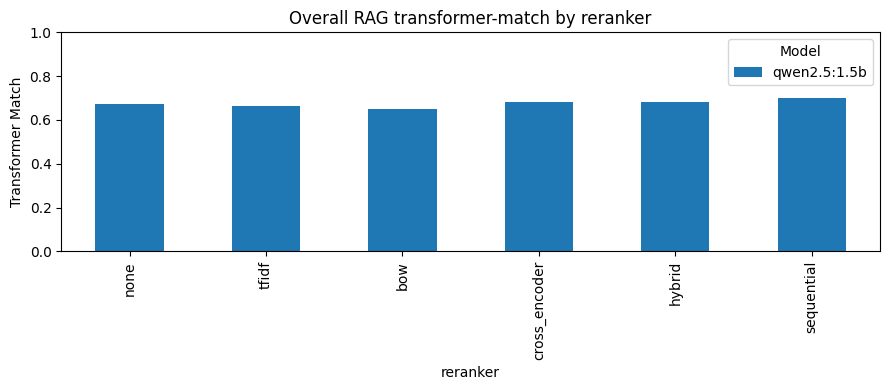

In [27]:
plot_df = overall_summary[overall_summary["model"] == "qwen2.5:1.5b"].copy()
pivot_df = plot_df.pivot(index="reranker", columns="model", values="transformer_match")

fig, ax = plt.subplots(figsize=(9, 4))
pivot_df.loc[["none", "tfidf", "bow", "cross_encoder", "hybrid", "sequential"]].plot(kind="bar", ax=ax)

ax.set_ylim(0, 1)
ax.set_ylabel("Transformer Match")
ax.set_title("Overall RAG transformer-match by reranker")
ax.legend(title="Model")
plt.tight_layout()
plt.show()

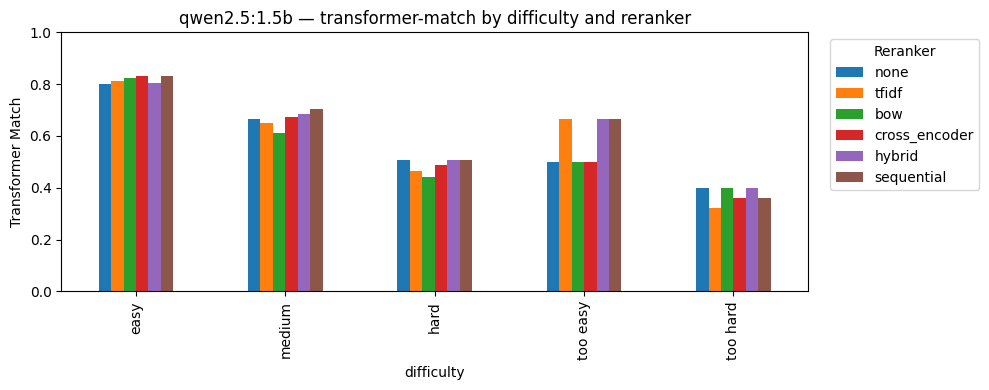

In [26]:
plot_df = difficulty_summary[difficulty_summary["model"] == "qwen2.5:1.5b"].copy()
pivot_df = (
    plot_df.pivot(index="difficulty", columns="reranker", values="transformer_match")
    .reindex(["easy", "medium", "hard", "too easy", "too hard"])
)

fig, ax = plt.subplots(figsize=(10, 4))
pivot_df.loc[:, ["none", "tfidf", "bow", "cross_encoder", "hybrid", "sequential"]].plot(kind="bar", ax=ax)

ax.set_ylim(0, 1)
ax.set_ylabel("Transformer Match")
ax.set_title("qwen2.5:1.5b — transformer-match by difficulty and reranker")
ax.legend(title="Reranker", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [22]:
print("difficulty_summary rerankers:")
print(sorted(difficulty_summary["reranker"].dropna().unique().tolist()))

print("\nqwen rerankers:")
print(sorted(
    difficulty_summary[difficulty_summary["model"] == "qwen2.5:1.5b"]["reranker"]
    .dropna().unique().tolist()
))


difficulty_summary rerankers:
['bow', 'cross_encoder', 'hybrid', 'none', 'sequential', 'tfidf']

qwen rerankers:
['bow', 'cross_encoder', 'hybrid', 'none', 'sequential', 'tfidf']

phi rerankers:
['none']


## Inspect a few examples

This helps identify whether rerankers are helping because they improve evidence ordering, or whether score changes are mostly due to generation variability.


In [21]:
display(
    combined_results_df[
        ["model", "reranker", "difficulty", "question", "gold_answer", "generated_answer", "exact_match", "transformer_match"]
    ].head(30)
)

,model,reranker,difficulty,question,gold_answer,generated_answer,exact_match,transformer_match
0,qwen2.5:1.5b,none,easy,Was Abraham Lincoln the sixteenth President of...,yes,"Yes, Abraham Lincoln was indeed the sixteenth ...",1.0,1.0
1,qwen2.5:1.5b,none,easy,Was Abraham Lincoln the sixteenth President of...,Yes.,"Yes, Abraham Lincoln was indeed the sixteenth ...",1.0,1.0
2,qwen2.5:1.5b,none,medium,Did Lincoln sign the National Banking Act of 1...,yes,No context,0.0,0.0
3,qwen2.5:1.5b,none,easy,Did Lincoln sign the National Banking Act of 1...,Yes.,No context,0.0,0.0
4,qwen2.5:1.5b,none,medium,Did his mother die of pneumonia?,no,No context.,1.0,1.0
5,qwen2.5:1.5b,none,easy,Did his mother die of pneumonia?,No.,No context.,1.0,1.0
6,qwen2.5:1.5b,none,easy,How many long was Lincoln's formal education?,18 months,Lincoln's formal education consisted of about ...,1.0,1.0
7,qwen2.5:1.5b,none,medium,How many long was Lincoln's formal education?,18 months.,The context states that Lincoln's formal educa...,1.0,1.0
8,qwen2.5:1.5b,none,easy,When did Lincoln begin his political career?,1832,Young Abraham Lincoln began his political care...,1.0,1.0
9,qwen2.5:1.5b,none,medium,When did Lincoln begin his political career?,1832.,Young Abraham Lincoln began his political care...,1.0,1.0
